In [3]:
import serial
import time
import numpy as np
import re

import socket
import os
import binascii
import struct

import matplotlib.pyplot as plt

import serial.tools.list_ports

ports = list(serial.tools.list_ports.comports())
for port in ports:
    print(port.device, port.description)

COM3 USB-Enhanced-SERIAL CH343 (COM3)


In [32]:
def parse_si5345_txt_file(file_path):
    result = bytearray()
    current_page = None
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        # 去除空行和注释行
        line = line.strip()
        if not line or line.startswith('#') or ',' not in line:
            continue
        
        # 分割地址和数据
        try:
            addr_data = line.split(',')
            address = int(addr_data[0].strip(), 16)
            data = int(addr_data[1].strip(), 16)
        except (ValueError, IndexError):
            # 如果解析失败，跳过这一行
            continue
        
        # 提取page和addr
        page = (address >> 8) & 0xFF
        addr = address & 0xFF
        
        # 如果遇到新的page，先写入page切换命令
        if page != current_page:
            result.extend([0x00, 0x01, 0x40, page])
            current_page = page
        
        # 写入地址和数据
        result.extend([0x00, addr, 0x40, data])
    
    # 配置002B寄存器为08，支持读取
    result.extend([0x00, 0x01, 0x40, 0x00])
    result.extend([0x00, 0x2B, 0x40, 0x08])
    return result

def config_si5345(config_data, com_port):
    """
    配置Si5345芯片
    
    参数:
    config_data: 由parse_si5345_txt_file生成的bytearray
    com_port: 串口端口号，例如 'COM3'
    """
    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF0
    ser.write(b'\xF0')

    # 发送配置数据的长度（2字节，大端序）
    length_bytes = len(config_data).to_bytes(2, byteorder='big')
    ser.write(length_bytes)
    
    # 发送配置数据
    for i in range(0, len(config_data), 2):
        # 每次发送两个字节
        bytes_to_send = config_data[i:i+2]
        ser.write(bytes_to_send)
        
        # 发送完第20个字节后等待300ms
        if i == 18:
            time.sleep(0.3)  # 等待300ms

    ser.close()

def read_si5345(page, addr, com_port):
    """
    配置Si5345芯片
    
    参数:
    config_data: 由parse_si5345_txt_file生成的bytearray
    com_port: 串口端口号，例如 'COM3'
    """
    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF1
    ser.write(b'\xF1')

    # 读取一个寄存器
    ser.write(b'\x00\x01')
    ser.write(b'\x40' + bytes([int(page, 16)]))
    ser.write(b'\x00' + bytes([int(addr, 16)]))
    ser.write(b'\x80\x00')
    result = ser.read(2).hex()
    ser.close()
    return result

def config_ad9253(test_mode, com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF2
    ser.write(b'\xF2')

    # 14bit, 0x56为125M， 0x50为20M
    sample_rate_reg = b'\x01\x00\x56'
    # sample_rate_reg = b'\x01\x00\x50'

    # 写完0x100寄存器后需要往0xFF中写0x01
    confirm_reg = b'\x00\xFF\x01'

    # test mode，0x0B: 1bit high, 0x04: checkerboard, 0x02: full scale
    if (test_mode == "none"):
        test_mode_reg = b'\x00\x0D\x00'
    elif (test_mode == "1bit high"):
        test_mode_reg = b'\x00\x0D\x0B'
    elif (test_mode == "checkerboard"):
        test_mode_reg = b'\x00\x0D\x04'
    elif (test_mode == "full scale"):
        test_mode_reg = b'\x00\x0D\x02'
    elif (test_mode == "mixed frequency"):
        test_mode_reg = b'\x00\x0D\x0C'        

    # output mode, 0x00输出为offset binary
    output_mode_reg = b'\x00\x14\x00'
    # output_mode_reg = b'\x00\x14\x01'

    # 发送配置数据的长度（2字节，大端序）
    length_bytes = len(sample_rate_reg + confirm_reg + test_mode_reg + output_mode_reg).to_bytes(2, byteorder='big')
    ser.write(length_bytes)
    
    ser.write(sample_rate_reg)
    ser.write(confirm_reg)
    ser.write(test_mode_reg)
    ser.write(output_mode_reg)

    ser.close()

def read_ad9253(addr1, addr2, com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    # 先发送0xF3
    ser.write(b'\xF3')

    # 读取一个寄存器
    ser.write(bytes([int(addr1, 16) | 0x80]) + bytes([int(addr2, 16)]))
    result = ser.read(1).hex()
    ser.close()
    return result

def config_dac128s085(channel, voltage, com_port):
    """
    配置DAC128S085
    
    参数:
    channel: 通道选择，可以是"A", "B", "C", "D", "E", "F", "G", "H", "all", "All"
    voltage: 电压值，范围0-3.3V
    com_port: 串口端口号，例如 'COM3'
    """
    # 验证电压范围
    if voltage < 0 or voltage > 3.3:
        raise ValueError("电压值必须在0-3.3V之间")
    
    # 计算DAC码值
    D = int(voltage * 4096 / 3.3)
    
    # 确定CMD值
    if channel.upper() == "A":
        cmd = 0b0000  # 0
    elif channel.upper() == "B":
        cmd = 0b0001  # 1
    elif channel.upper() == "C":
        cmd = 0b0010  # 2
    elif channel.upper() == "D":
        cmd = 0b0011  # 3
    elif channel.upper() == "E":
        cmd = 0b0100  # 4
    elif channel.upper() == "F":
        cmd = 0b0101  # 5
    elif channel.upper() == "G":
        cmd = 0b0110  # 6
    elif channel.upper() == "H":
        cmd = 0b0111  # 7
    elif channel.upper() == "ALL":
        cmd = 0b1100  # 12
    else:
        raise ValueError("不支持的通道，有效通道为: A, B, C, D, E, F, G, H, all, All")
    
    # 构建16位数据DB[15:0]
    # DB[15:12] = cmd, DB[11:0] = D
    db = (cmd << 12) | (D & 0xFFF)  # 确保D只取低12位
    # db >>= 1

    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)
    
    # 发送0xF6
    ser.write(b'\xFC')
    # 配置WTM模式
    ser.write(bytes([0b10010000, 0b00000000]))
    
    ser.write(b'\xFC')
    # 发送16位数据（大端序）
    data_bytes = db.to_bytes(2, byteorder='big')
    ser.write(data_bytes)
        
    ser.close()
    
def idelay(com_port, cha0 = 0, cha1 = 0, chb0 = 0, chb1 = 0, chc0 = 0, chc1 = 0, chd0 = 0, chd1 = 0):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)
    ser.write(b'\xFE')

    values = [cha0, cha1, chb0, chb1, chc0, chc1, chd0, chd1]
    for value in values:
        # 将数值转换为16进制字节
        hex_byte = value.to_bytes(1, byteorder='big')
        ser.write(hex_byte)
    ser.close()


In [37]:
def ad9253_bitslip(channel, com_port, time_err=1.0):
    # 通道 → 指令映射
    cmd_map = {
        "cha0": b'\xF4',
        "cha1": b'\xF5',
        "chb0": b'\xF6',
        "chb1": b'\xF7',
        "chc0": b'\xF8',
        "chc1": b'\xF9',
        "chd0": b'\xFA',
        "chd1": b'\xFB',
    }

    # 通道 → 正确数据模式映射
    target_map = {
        "cha0": "10011100",
        "cha1": "10100001",
        "chb0": "10011100",
        "chb1": "10100001",
        "chc0": "10011100",
        "chc1": "10100001",
        "chd0": "10011100",
        "chd1": "10100001",
    }

    if channel not in cmd_map:
        raise ValueError(f"Invalid channel: {channel}")

    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)
    start_time = time.time()

    try:
        while True:
            # 超时判断
            if time.time() - start_time > time_err:
                print(f"{channel} bitslip error.")
                return False

            # print(f"{channel} bitslipping ..")

            ser.write(cmd_map[channel])
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                return False

            result = format(data[0], '08b')

            if result == target_map[channel]:
                print(f"{channel} bitslip done.")
                return True

            time.sleep(0.1)

    finally:
        ser.close()

In [ ]:
def find_best_delays(delays_matrix):
    delays = []

    for ch in range(delays_matrix.shape[0]):
        row = delays_matrix[ch]
        n = len(row)

        # 关键：拼接一份，处理环形
        extended = np.concatenate([row, row])

        max_len = 0
        max_start = 0

        curr_len = 0
        curr_start = 0

        for i in range(len(extended)):
            if extended[i] == 1:
                if curr_len == 0:
                    curr_start = i
                curr_len += 1

                if curr_len > max_len:
                    max_len = curr_len
                    max_start = curr_start
            else:
                curr_len = 0

        if max_len == 0:
            # 没有可用点
            delays.append(None)
            continue

        # 中点（取整数）
        center = max_start + max_len // 2

        # 映射回 0~31
        delay = center % n

        delays.append(delay)

    return delays

def ad9253_delay_cali(com_port, time_err=1.0):
    delays_matrix = np.zeros((8, 32), dtype=int)
    channel_map = ["cha0", "cha1", "chb0", "chb1", "chc0", "chc1", "chd0", "chd1"]

    for channel in range(8):
        for delay in range(32):
            delays = [0, 0, 0, 0, 0, 0, 0, 0]
            delays[channel] = delay
            
            idelay(
                com_port, 
                cha0=delays[0], 
                cha1=delays[1], 
                chb0=delays[2], 
                chb1=delays[3], 
                chc0=delays[4], 
                chc1=delays[5], 
                chd0=delays[6], 
                chd1=delays[7]
            )

            time.sleep(0.05)
            if (ad9253_bitslip(channel_map[channel], com_port, time_err)):
                delays_matrix[channel, delay] = 1
            time.sleep(0.05)
            
    print(delays_matrix)

    best_delays = find_best_delays(delays_matrix)
    print(best_delays)
    idelay(
        com_port, 
        cha0=best_delays[0], 
        cha1=best_delays[1], 
        chb0=best_delays[2], 
        chb1=best_delays[3], 
        chc0=best_delays[4], 
        chc1=best_delays[5], 
        chd0=best_delays[6],
        chd1=best_delays[7] 
    )
    for channel in range(8):
        ad9253_bitslip(channel_map[channel], com_port, time_err)

In [4]:
def ad9253_bitslip0_ch1(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xF4')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10011100":
                print("bitslip0_ch1 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip0_ch2(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xF6')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10011100":
                print("bitslip0_ch2 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip0_ch3(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xF8')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10011100":
                print("bitslip0_ch3 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip0_ch4(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xFA')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10011100":
                print("bitslip0_ch4 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip1_ch1(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xF5')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10100001":
                print("bitslip1_ch1 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip1_ch2(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xF7')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10100001":
                print("bitslip1_ch2 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip1_ch3(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xF9')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10100001":
                print("bitslip1_ch3 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

def ad9253_bitslip1_ch4(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=0.1, stopbits=2)

    try:
        while True:
            ser.write(b'\xFB')
            time.sleep(0.01)

            data = ser.read(1)
            if len(data) == 0:
                print("No data received")
                continue

            result = format(data[0], '08b')
            print(result)

            if result == "10100001":
                print("bitslip1_ch4 done")
                break

            time.sleep(0.1)

    finally:
        ser.close()

In [5]:
def receive_one_packet_uart(com_port, N=59, path="E:\\data_test\\uart_data.bin"):
    """
    通过串口接收数据包并解析，然后保存和绘图（大端序解析）
    
    参数:
        com_port: 串口端口号，例如'COM3'
        N: 数据点数量，默认30
        path: 保存文件路径，默认"E:\\data_test\\uart_data.bin"
    """
    import struct
    import matplotlib.pyplot as plt

    # 计算总接收字节数
    total_bytes = (N + 5) * 2  # (N + 5) 个16位整数
    
    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=3.0, stopbits=2)

    ser.write(b'\xFD')
    time.sleep(0.01)

    try:
        # 接收数据
        data = b""
        remaining = total_bytes
        while remaining > 0:
            chunk = ser.read(remaining)
            if not chunk:
                print(f"警告: 只接收到 {len(data)} 字节，期望 {total_bytes} 字节")
                break
            data += chunk
            remaining -= len(chunk)
        
        if len(data) < total_bytes:
            print(f"警告: 只接收到 {len(data)} 字节，期望 {total_bytes} 字节")
            return None
        
        # -----------------------
        # 解析 header (大端)
        # -----------------------
        trig_id = struct.unpack('>H', data[0:2])[0]  # 大端 16-bit
        channel_num = struct.unpack('>H', data[2:4])[0]
        
        # trig_time: 48-bit 大端
        trig_time_bytes = data[4:10]
        trig_time = int.from_bytes(trig_time_bytes, byteorder='big')
        trig_time_seconds = trig_time * 8e-9  # LSB = 8ns
        
        # -----------------------
        # 解析数据部分，每个点 16-bit 大端
        # -----------------------
        data_points_bytes = data[10:]
        data_points = []
        for i in range(0, len(data_points_bytes) - 1, 2):
            byte1 = data_points_bytes[i]
            byte2 = data_points_bytes[i+1]
            # 取byte2的前6位
            byte2_6bit = byte2 >> 2
            # 拼在一起形成14-bit点
            point = (byte1 << 6) | byte2_6bit
            data_points.append(point)
        
        # -----------------------
        # 保存数据到文件
        # -----------------------
        save_data = b""
        save_data += data[0:10] 
        for point in data_points:
            save_data += struct.pack('>H', point)     # 16-bit 大端
        
        with open(path, 'wb') as f:
            f.write(save_data)
        
        # -----------------------
        # 绘图
        # -----------------------
        if data_points:
            x_values = list(range(len(data_points)))
            plt.figure(figsize=(12, 6))
            plt.plot(x_values, data_points, marker='o', linestyle='-', markersize=4)
            plt.title(f'UART Data Plot - Trig ID: {trig_id}, Channel Number: {channel_num}, Trig Time: {trig_time_seconds:.2e}s, Points: {len(data_points)}')
            plt.xlabel('Index')
            plt.ylabel('Value')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print(f"接收到的UART数据包:")
            print(f"Trig ID: {trig_id}")
            print(f"Channel Number: {channel_num}")
            print(f"Trig Time: {trig_time_seconds:.2e} s ({trig_time} * 8e-9)")
            print(f"数据点数量: {len(data_points)}")
            
        else:
            print("没有有效的数据点来绘制")
            return None
            
    finally:
        ser.close()


def receive_and_save_data_uart(com_port, n=59, path="E:\\data_test\\uart_data.bin", N=100):
    """
    通过串口接收数据并按数据块写入文件（16进制文本）

    参数:
    com_port : 串口端口号，例如'COM3'
    n      : 每个数据块中 data 的数量（每个 data 为 16bit）
    path   : 保存路径
    N      : 数据块数量
    """

    bytes_per_block = (n + 5) * 2   # 每个 word = 2 字节

    # 打开串口
    ser = serial.Serial(com_port, baudrate=1000000, timeout=3.0, stopbits=2)

    ser.write(b'\xFD')
    time.sleep(0.01)
    
    try:
        with open(path, 'wb') as f:
            for blk in range(N):
                block = b''

                # 确保接收完整一个数据块
                while len(block) < bytes_per_block:
                    chunk = ser.read(bytes_per_block - len(block))
                    if not chunk:
                        print(f"串口关闭或接收超时，已接收 {blk} 个数据块")
                        return
                    block += chunk

                header = block[0:10]
                data_points_bytes = block[10:]
                data_points = []
                for i in range(0, len(data_points_bytes) - 1, 2):
                    byte1 = data_points_bytes[i]
                    byte2 = data_points_bytes[i+1]
                    # 取byte2的前6位
                    byte2_6bit = byte2 >> 2
                    # 拼在一起形成14-bit点
                    point = (byte1 << 6) | byte2_6bit
                    data_points.append(point)

                f.write(header)
                for point in data_points:
                    f.write(struct.pack('>H', point))

        print(f"已通过UART接收并保存 {N} 个数据块, 每个数据块中有 {n + 5} 个数据点")
        
    finally:
        ser.close()

def stop_trans(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=1.0, stopbits=2)

    ser.write(b'\xFE')
    time.sleep(0.01)

    ser.close()

def read_all_uart(com_port):
    ser = serial.Serial(com_port, baudrate=1000000, timeout=1.0, stopbits=2)
    data = ser.read_all()
    print(len(data))
    print(data)

In [6]:
    
def receive_one_packet(socket, N=30, path="E:\\data_test\\tcp_data.bin"):
    """
    接收数据包并解析，然后保存和绘图（大端序解析）
    
    参数:
        socket: 已连接的socket对象
        N: 数据点数量，默认120
        path: 保存文件路径，默认"E:\\data_test\\tcp_data.bin"
    """
    import struct
    import matplotlib.pyplot as plt
    
    # 计算总接收字节数
    total_bytes = (N + 5) * 2  # (N + 5) 个16位整数
    
    # 接收数据
    data = b""
    remaining = total_bytes
    while remaining > 0:
        chunk = socket.recv(remaining)
        if not chunk:
            break
        data += chunk
        remaining -= len(chunk)
    
    if len(data) < total_bytes:
        print(f"警告: 只接收到 {len(data)} 字节，期望 {total_bytes} 字节")
        return None
    
    # -----------------------
    # 解析 header (大端)
    # -----------------------
    trig_id = struct.unpack('>H', data[0:2])[0]  # 大端 16-bit
    channel_num = struct.unpack('>H', data[2:4])[0]
    
    # trig_time: 48-bit 大端
    trig_time_bytes = data[4:10]
    trig_time = int.from_bytes(trig_time_bytes, byteorder='big')
    trig_time_seconds = trig_time * 8e-9  # LSB = 8ns
    
    # -----------------------
    # 解析数据部分，每个点 16-bit 大端
    # -----------------------
    data_points_bytes = data[10:]
    data_points = []
    for i in range(0, len(data_points_bytes) - 1, 2):
        byte1 = data_points_bytes[i]
        byte2 = data_points_bytes[i+1]
        # 取byte2的前6位
        byte2_6bit = byte2 >> 2
        # 拼在一起形成14-bit点
        point = (byte1 << 6) | byte2_6bit
        data_points.append(point)
    
    # -----------------------
    # 保存数据到文件
    # -----------------------
    save_data = b""
    save_data += data[0:10] 
    for point in data_points:
        save_data += struct.pack('>H', point)     # 16-bit 大端
    
    with open(path, 'wb') as f:
        f.write(save_data)
    
    # -----------------------
    # 绘图
    # -----------------------
    if data_points:
        import matplotlib.pyplot as plt
        x_values = list(range(len(data_points)))
        plt.figure(figsize=(12, 6))
        plt.plot(x_values, data_points, marker='o', linestyle='-', markersize=4)
        plt.title(f'Data Plot - Trig ID: {trig_id}, Channel Number: {channel_num}, Trig Time: {trig_time_seconds:.2f}s, Points: {len(data_points)}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"接收到的数据包:")
        print(f"Trig ID: {trig_id}")
        print(f"Channel Number: {channel_num}")
        print(f"Trig Time: {trig_time_seconds:.2e} s ({trig_time} * 8e-9)")
        print(f"数据点数量: {len(data_points)}")
        
        # return {
        #     'trig_id': trig_id,
        #     'channel_num': channel_num,
        #     'trig_time': trig_time,
        #     'trig_time_seconds': trig_time_seconds,
        #     'data_points': data_points
        # }
    else:
        print("没有有效的数据点来绘制")
        return None


def receive_and_save_data(socket, n=30, path="E:\\data_test\\tcp_data.bin", N=300):
    """
    接收数据并按数据块写入文件（16进制文本）

    参数:
    socket : TCP socket
    n      : 每个数据块中 data 的数量（每个 data 为 16bit）
    path   : 保存路径
    N      : 数据块数量
    """

    bytes_per_block = (n + 5) * 2   # 每个 word = 2 字节

    with open(path, 'w') as f:
        for blk in range(N):
            block = b''

            # 确保接收完整一个数据块
            while len(block) < bytes_per_block:
                chunk = socket.recv(bytes_per_block - len(block))
                if not chunk:
                    print("socket closed unexpectedly")
                    return
                block += chunk

            data_points_bytes = block[10:]
            data_points = []
            for i in range(0, len(data_points_bytes) - 1, 2):
                byte1 = data_points_bytes[i]
                byte2 = data_points_bytes[i+1]
                # 取byte2的前6位
                byte2_6bit = byte2 >> 2
                # 拼在一起形成14-bit点
                point = (byte1 << 6) | byte2_6bit
                data_points.append(point)
            
            save_data = b""
            save_data += block[0:10] 
            for point in data_points:
                save_data += struct.pack('>H', point)     # 16-bit 大端
                    
            f.write(save_data)
            # 一个数据块结束后换行
            f.write("\n")

    print(f"已接收并保存 {N} 个数据块, 每个数据块中有 {n + 5} 个数据点")

In [49]:
idelay("com3", chd1 = 18)

In [ ]:
best_delays = [2, 17, 28, 5, 2, 6, 29, 18]
idelay(
    "COM3", 
    cha0=best_delays[0], 
    cha1=best_delays[1], 
    chb0=best_delays[2], 
    chb1=best_delays[3], 
    chc0=best_delays[4], 
    chc1=best_delays[5], 
    chd0=best_delays[6],
    chd1=best_delays[7] 
)
channel_map = ["cha0", "cha1", "chb0", "chb1", "chc0", "chc1", "chd0", "chd1"]
for channel in range(8):
    ad9253_bitslip(channel_map[channel], "COM3", 1.0)

cha0 bitslip done.
cha1 bitslip done.
chb0 bitslip done.
chb1 bitslip done.
chc0 bitslip done.
chc1 bitslip done.
chd0 bitslip done.
chd1 bitslip error.


In [45]:
si5345_config_data_125M = parse_si5345_txt_file("Si5345-RevD-5345CONF-Registers_125M.txt")
config_si5345(si5345_config_data_125M, 'COM3')

# si5345_config_data_20M = parse_si5345_txt_file("Si5345-RevD-5345CONF-Registers_20M.txt")
# config_si5345(si5345_config_data_20M, 'COM3')

print("si5345 reg:")
print(read_si5345("01", "1C", 'COM3'))
config_dac128s085("all", 1.93, "COM3")
time.sleep(5)

si5345 reg:
06


In [46]:
config_dac128s085("D", 1.92, "COM3")
config_dac128s085("C", 1.90, "COM3")
config_dac128s085("B", 2, "COM3")
config_dac128s085("A", 2, "COM3")

In [47]:
config_ad9253("mixed frequency", "COM3")
print("ad9253 reg:")
print(read_ad9253("00", "0D", 'COM3'))

ad9253 reg:
0c


In [48]:
ad9253_delay_cali("COM3", time_err=1.0)

cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip error.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip error.
cha0 bitslip error.
cha0 bitslip error.
cha0 bitslip error.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha0 bitslip done.
cha1 bitslip error.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip error.
cha1 bitslip error.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1 bitslip done.
cha1

In [200]:
config_ad9253("none", "COM3")

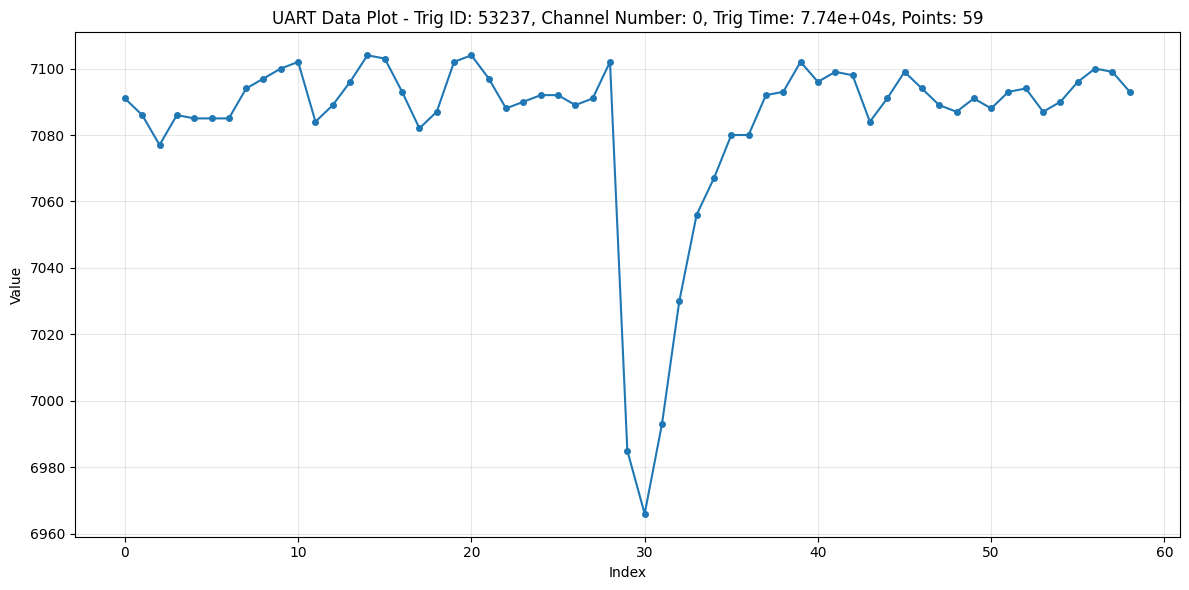

接收到的UART数据包:
Trig ID: 53237
Channel Number: 0
Trig Time: 7.74e+04 s (9675445180119 * 8e-9)
数据点数量: 59


In [213]:
receive_one_packet_uart("COM3")

In [209]:
stop_trans("COM3")

In [210]:
receive_and_save_data_uart("COM3", N=300)

已通过UART接收并保存 300 个数据块, 每个数据块中有 64 个数据点


In [159]:
read_all_uart("COM3")

0
b''


In [29]:
client = socket.socket(family=socket.AF_INET, type=socket.SOCK_STREAM)
client.settimeout(3)
client.connect(('192.168.10.16', 24))
client

TimeoutError: timed out

In [251]:
client.close()

NameError: name 'client' is not defined

In [32]:
si5345_config_data_125M = parse_si5345_txt_file("Si5345-RevD-5345CONF-Registers_125M.txt")
config_si5345(si5345_config_data_125M, 'COM4')

# si5345_config_data_20M = parse_si5345_txt_file("Si5345-RevD-5345CONF-Registers_20M.txt")
# config_si5345(si5345_config_data_20M, 'COM4')

print("si5345 reg:")
print(read_si5345("01", "1C", 'COM4'))
config_dac128s085("all", 1.93, "COM4")
time.sleep(5)

config_ad9253("mixed frequency", "COM4")
print("ad9253 reg:")
print(read_ad9253("00", "0D", 'COM4'))

SerialException: could not open port 'COM4': FileNotFoundError(2, '系统找不到指定的文件。', None, 2)

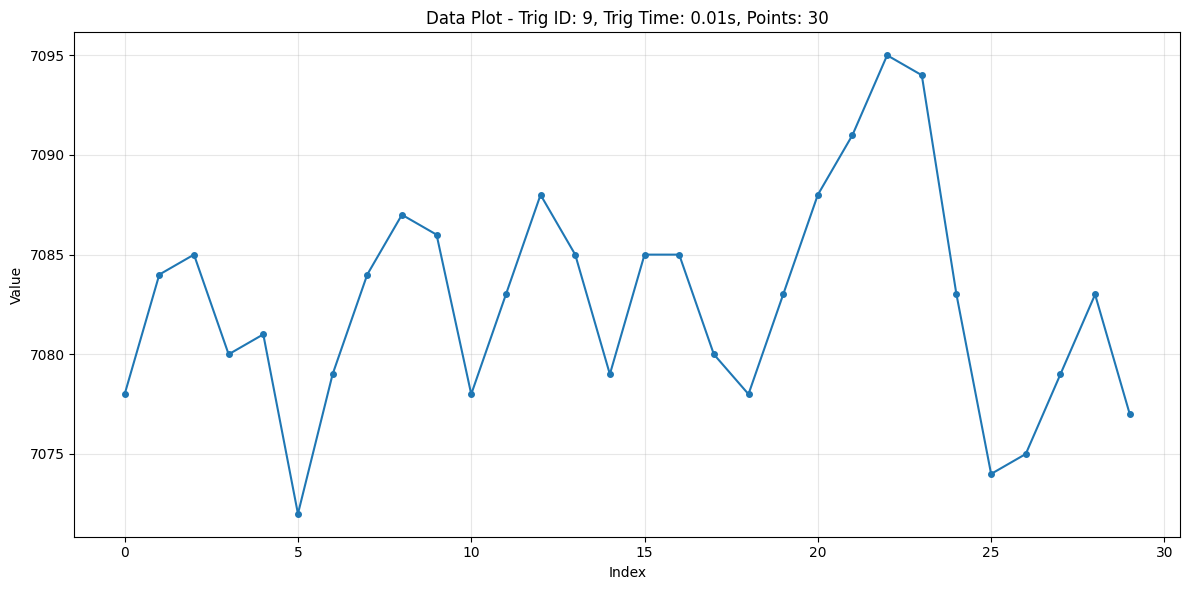

接收到的数据包:
Trig ID: 9
Trig Time: 1.33e-02 s (1657688 * 8e-9)
数据点数量: 30


{'trig_id': 9,
 'trig_time': 1657688,
 'trig_time_seconds': 0.013261504,
 'data_points': [7078,
  7084,
  7085,
  7080,
  7081,
  7072,
  7079,
  7084,
  7087,
  7086,
  7078,
  7083,
  7088,
  7085,
  7079,
  7085,
  7085,
  7080,
  7078,
  7083,
  7088,
  7091,
  7095,
  7094,
  7083,
  7074,
  7075,
  7079,
  7083,
  7077]}

In [218]:
# i = 0
# while(i < 100):
#     receive_one_packet(client)
#     i = i + 1
#     time.sleep(0.001)
receive_one_packet(client)

In [69]:
ser = serial.Serial("COM3", baudrate=1000000, timeout=0.1, stopbits=2)
data = ser.read(1)
print(data)
ser.close()

b''


In [67]:
ser.close()